Mass of exoplanets orbiting in 55 Cancri
Amy Tran

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

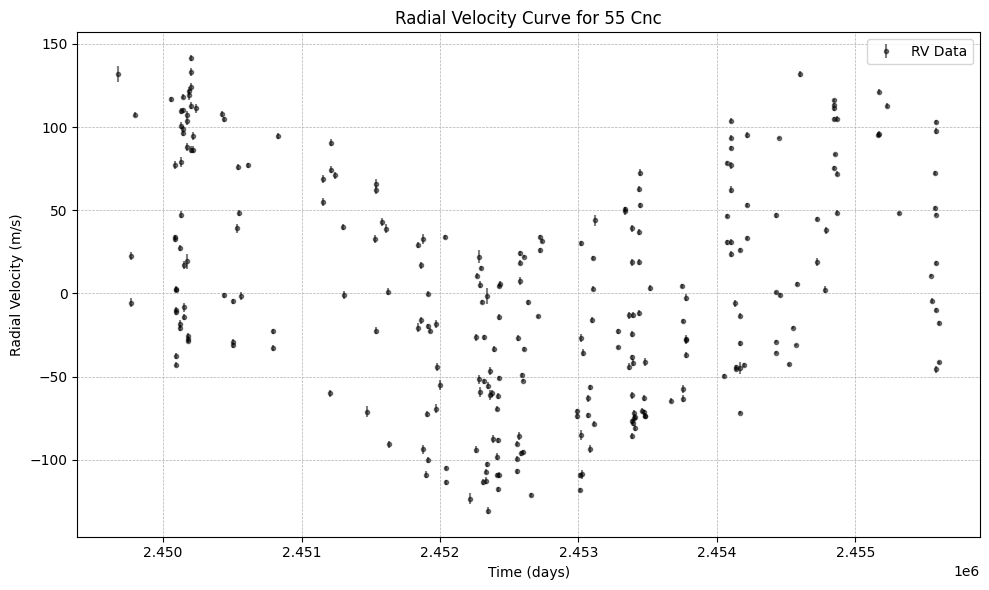

In [ ]:
data = np.loadtxt('55cnc_rv.txt')
time = data[:, 0]
rv = data[:, 1]
err = data[:, 2]

#RV vs Time: Dot Plot
plt.figure(figsize=(10, 6))
plt.errorbar(time, rv, yerr=err, fmt='o', markersize=3, 
             color='black', alpha=0.5, label='RV Data')
plt.xlabel('Time (days)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('Radial Velocity Curve for 55 Cnc')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Fitted Amplitude K = 3.1449 m/s
Fitted Period P = 0.736500 days
Fitted Phase = -4.9904 rad
Fitted Offset = 0.4974 m/s


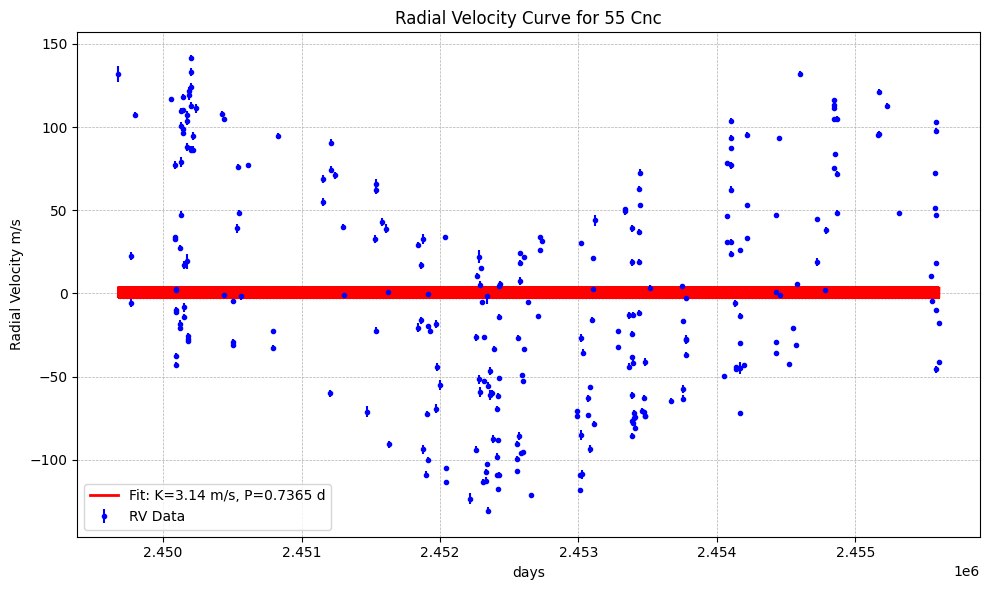

In [29]:

def rv_model(t, amp, period, phase, offset):
    return amp * np.sin(2 * np.pi * t / period + phase) + offset

p0 = [6, 0.7365, 0, np.mean(rv)]
params, _ = curve_fit(rv_model, time, rv, p0=p0)
amp, period, phase, offset = params

print(f"Fitted Amplitude K = {amp:.4f} m/s")
print(f"Fitted Period P = {period:.6f} days")
print(f"Fitted Phase = {phase:.4f} rad")
print(f"Fitted Offset = {offset:.4f} m/s")

# Plot data, fit
time_fit = np.linspace(min(time), max(time), 10000)
rv_fit = rv_model(time_fit, *params)

plt.figure(figsize=(10, 6))
plt.errorbar(time, rv, yerr=err, fmt='o', markersize=3,
             color='blue', label='RV Data')
plt.plot(time_fit, rv_fit, color='red', linewidth=2,
         label=f'Fit: K={amp:.2f} m/s, P={period:.4f} d')
plt.xlabel('days')
plt.ylabel('Radial Velocity m/s')
plt.title('Radial Velocity Curve for 55 Cnc')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

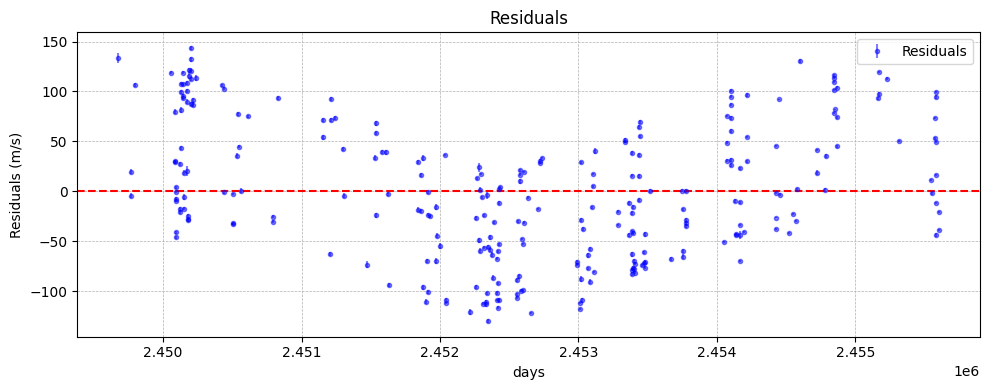

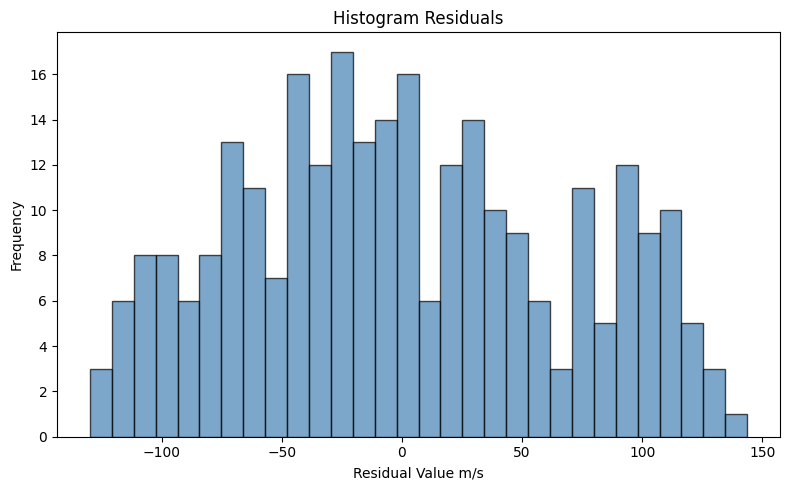

Standard Deviation: 67.03 m/s
Mean Error: 1.81 m/s
Ratio: 37.1x


In [ ]:
residuals = rv - rv_model(time, *params)

# residuals vs time
plt.figure(figsize=(10, 4))
plt.errorbar(time, residuals, yerr=err, fmt='o', markersize=3,
             color='blue', alpha=0.5, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('days')
plt.ylabel('Residuals (m/s)')
plt.title('Residuals')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Histogram 
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Residual Value m/s')
plt.ylabel('Frequency')
plt.title('Histogram Residuals')
plt.tight_layout()
plt.show()

#compare
std_residuals = np.std(residuals)
mean_error = np.mean(err)
print(f"Standard Deviation: {std_residuals:.2f} m/s")
print(f"Mean Error: {mean_error:.2f} m/s")
print(f"Ratio: {std_residuals/mean_error:.1f}x")

In [ ]:
#mass calculation
K = abs(amp)        # amplitude in m/s
P = abs(period)     # period in days 
M_star = 0.905      # 55 Cnc stellar mass in solar masses

M_jup = (K / 28.4) * (P / 365)**(1/3) * (M_star)**(2/3)
M_earth = M_jup * 317.8

print(f"K      = {K:.4f} m/s")
print(f"P      = {P:.4f} days")
print(f"M_star = {M_star} solar mass(es)")
print(f"M_planet = {M_jup:.5f} Jupiter mass(es)")
print()
print("The exoplanet is known as 55 cnc e, a super 'Earth' like planet.")


K      = 3.1449 m/s
P      = 0.7365 days
M_star = 0.905 solar masses
M_planet = 0.01309 Jupiter masses

The exoplanet is known as 55 cnc e, a super 'Earth' like planet.
